# 집 가격 예측 2019 캐글 ML 대회

## 1. EDA + Preprocessing

In [25]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

print('import 완료')

import 완료


In [26]:
from pathlib import Path
data_dir = Path('./data')

train_data_path = join(data_dir, 'train.csv')
test_data_path = join(data_dir, 'test.csv')

train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

train.head()

print("data파일 불러오기 완료")

data파일 불러오기 완료


In [27]:
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)

print('date column 형식을 int로 변환')
train.head()

date column 형식을 int로 변환


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,201410,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,201502,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,201502,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,201406,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,201501,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [28]:
y = train['price']
del train['price']

print(train.columns)

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='str')


In [29]:
del train['id']

print('id column도 삭제')

id column도 삭제


In [30]:
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

del test['id']

print('train data도 date를 int형으로 바꾸고 id 삭제')

train data도 date를 int형으로 바꾸고 id 삭제


In [31]:
y

0         221900.0
1         180000.0
2         510000.0
3         257500.0
4         291850.0
           ...    
15030     610685.0
15031    1007500.0
15032     360000.0
15033     400000.0
15034     325000.0
Name: price, Length: 15035, dtype: float64

## y 분포도 확인

y는 np.log1p() 함수를 통해 로그 변환을 해주고, 나중에 모델이 값을 예측한 후에 다시 np.expm1()을 활용해서 되돌리겠습니다. np.expm1()은 np.log1p()과는 반대로 각 원소 x마다 exp(x)-1의 값을 반환해 줍니다.

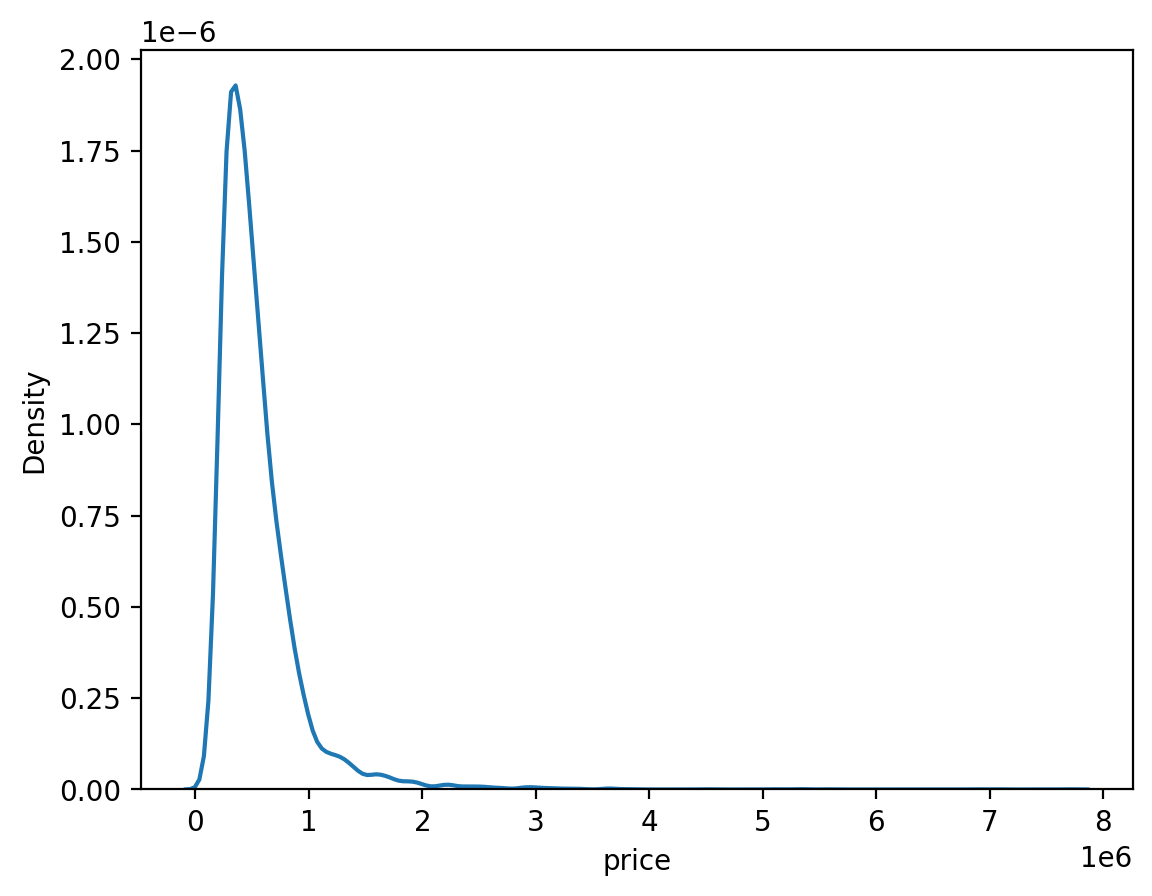

In [32]:
"""
seaborn의 `kdeplot`을 활용해 `y`의 분포를 확인해주세요!
"""

#코드 작성
sns.kdeplot(y)
plt.show()

In [33]:
y = np.log1p(y)

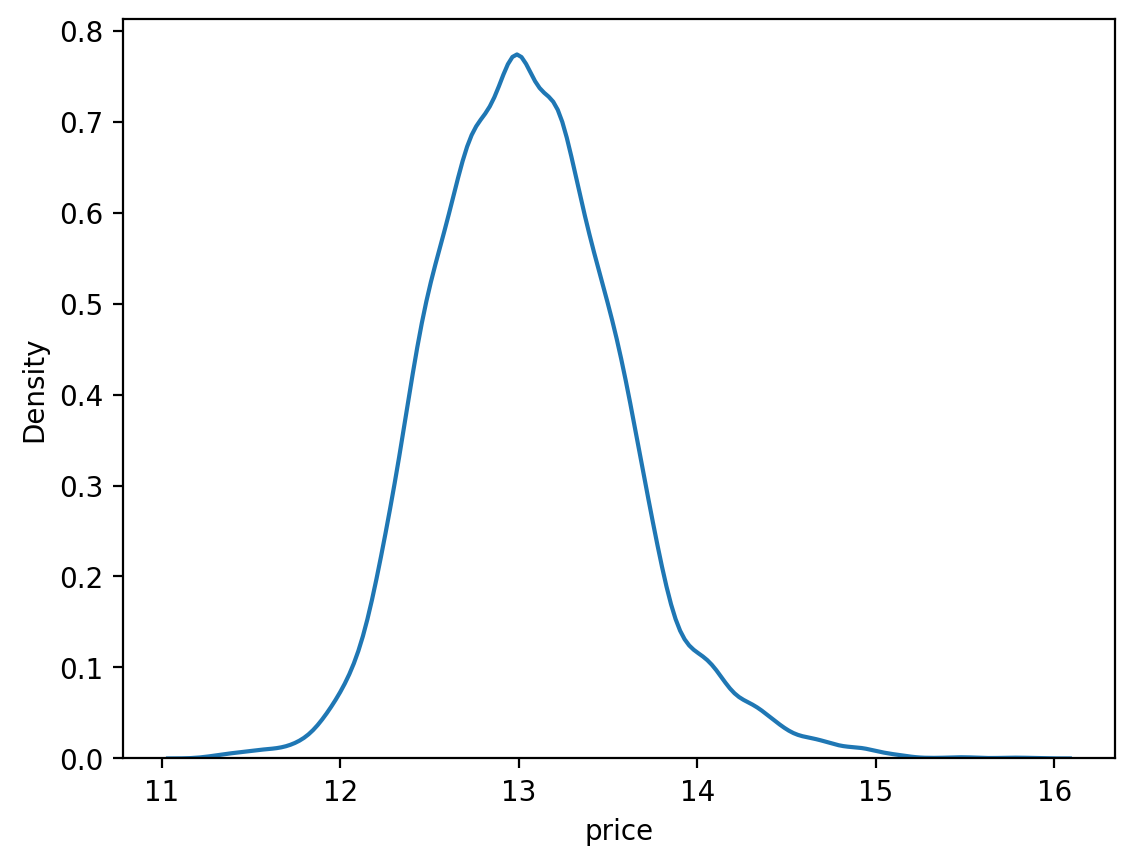

In [34]:
sns.kdeplot(y)
plt.show()

### train columns의 자료형 확인 
모두 숫자형 데이터면 모델이 학습에 사용가능

In [35]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           15035 non-null  int64  
 1   bedrooms       15035 non-null  int64  
 2   bathrooms      15035 non-null  float64
 3   sqft_living    15035 non-null  int64  
 4   sqft_lot       15035 non-null  int64  
 5   floors         15035 non-null  float64
 6   waterfront     15035 non-null  int64  
 7   view           15035 non-null  int64  
 8   condition      15035 non-null  int64  
 9   grade          15035 non-null  int64  
 10  sqft_above     15035 non-null  int64  
 11  sqft_basement  15035 non-null  int64  
 12  yr_built       15035 non-null  int64  
 13  yr_renovated   15035 non-null  int64  
 14  zipcode        15035 non-null  int64  
 15  lat            15035 non-null  float64
 16  long           15035 non-null  float64
 17  sqft_living15  15035 non-null  int64  
 18  sqft_lot15     15

## 2. Hyper Parameter

### 전처리에 필요한 라이브러리 import 하고 재사용 가능한 변수&함수 만들기

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [37]:
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

In [38]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

### 네 가지 모델 이름. models에 저장

In [39]:
random_state=2020        # 하지만 우리는 이렇게 고정값을 세팅해 두겠습니다.

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest]

In [40]:
df = {}

for model in models:
    # 모델 이름 획득
    model_name = model.__class__.__name__

    # train, test 데이터셋 분리
    # random_state를 사용하여 고정하고 train과 test 셋의 비율은 8:2로 합니다.
    X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)


    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 예측 결과의 rmse값 저장
    df[model_name] = rmse(y_test, y_pred)

    # data frame에 저장
    score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

df

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000728 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.047779


{'GradientBoostingRegressor': np.float64(128360.19649691368),
 'XGBRegressor': np.float64(117618.22328886154),
 'LGBMRegressor': np.float64(111920.36735892233),
 'RandomForestRegressor': np.float64(125426.50084175983)}

In [41]:
def get_scores(models, train, y):
    df = {}

    for model in models:
        model_name = model.__class__.__name__

        X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        df[model_name] = rmse(y_test, y_pred)
        score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

    return score_df

#### 그리드탐색

In [42]:
from sklearn.model_selection import GridSearchCV

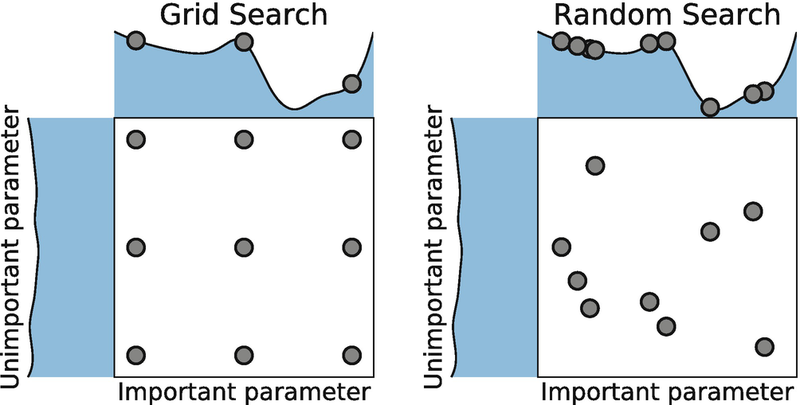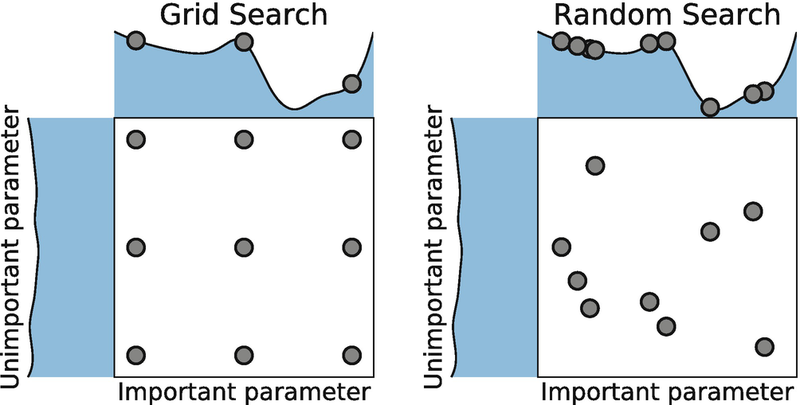

In [43]:
param_grid = {
    'n_estimators': [100, 500, 1000],  # 더 많은 나무를 시도
    'max_depth': [5, 10, 15],           # 적절한 깊이 탐색
    'learning_rate': [0.01, 0.05, 0.1] # 학습률 조절은 성능에 매우 큰 영향을 줍니다!
}



In [44]:
model = LGBMRegressor(random_state=random_state, n_estimators=100, verbosity=-1)

In [45]:
grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=0, n_jobs=5)

In [46]:
grid_model.fit(train, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 10, ...], 'n_estimators': [100, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

#### CV 결과보기

In [47]:
grid_model.cv_results_

{'mean_fit_time': array([ 5.05351887,  4.2493443 ,  6.82650566,  1.44413762,  5.31337457,
        10.16226444,  1.30896001,  6.07621179, 11.4642601 ,  0.95664606,
         3.01170149,  5.752775  ,  1.29392271,  5.19877162,  9.26004219,
         1.337747  ,  4.9716023 , 10.21671648,  1.13957229,  3.04227962,
         6.20420489,  1.37298594,  5.04414415,  9.22817311,  1.30428672,
         5.61163335,  9.96720729]),
 'std_fit_time': array([0.06338335, 0.07725321, 0.14751775, 0.04681148, 0.35458651,
        0.12046231, 0.05206067, 0.05120976, 0.08566083, 0.09589151,
        0.06096301, 0.05892021, 0.1155977 , 0.07884153, 0.3379091 ,
        0.1047039 , 0.06983464, 0.3565984 , 0.01134725, 0.09456788,
        0.1559362 , 0.1687125 , 0.1189314 , 0.41762803, 0.09316311,
        0.06575268, 0.28317001]),
 'mean_score_time': array([0.00544186, 0.01352053, 0.02555008, 0.00440588, 0.01250882,
        0.02329006, 0.00410218, 0.01221318, 0.02283354, 0.00400543,
        0.01071005, 0.0195231 , 0.004

### 1번째 GridSearchCV 결과
#### 분석
rank_test_score를 보면 14번째 인덱스가 1등을 한것으로 나옵니다.
14번째 인덱스 값은  {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 500}, 입니다.

#### 파라미터를 좀더 세밀하게 조정
learning_rate: [0.03, 0.05, 0.07]
n_estimators: [400, 500, 600]
max_depth: [8, 10, 12] 



In [48]:
param_grid = {
    'n_estimators': [400, 500, 600],  
    'max_depth': [8, 10, 12],           
    'learning_rate': [0.03, 0.05, 0.07] 
}

grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=0, n_jobs=5)

grid_model.fit(train, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.05, ...], 'max_depth': [8, 10, ...], 'n_estimators': [400, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [49]:
grid_model.cv_results_

{'mean_fit_time': array([4.91497989, 4.85095716, 5.72276087, 4.70377913, 5.54460387,
        6.23541956, 4.9675076 , 6.3928195 , 8.21882792, 5.17095389,
        5.1195919 , 5.85514393, 4.46995935, 5.46724625, 6.16737671,
        4.78520455, 5.29602394, 5.95406985, 3.72475791, 4.64960117,
        5.78723001, 4.19776831, 5.11807566, 5.64186478, 4.11029191,
        5.03272786, 5.52888837]),
 'std_fit_time': array([0.10822899, 0.13512285, 0.02047731, 0.07756542, 0.04609024,
        0.17097001, 0.49201585, 0.14560821, 0.59784124, 0.37154071,
        0.15083956, 0.37034978, 0.31885752, 0.07979385, 0.09937112,
        0.06273011, 0.07810518, 0.49410286, 0.12412539, 0.30157033,
        0.4356235 , 0.31149747, 0.09082778, 0.36318969, 0.28920605,
        0.09866156, 0.24823915]),
 'mean_score_time': array([0.01472359, 0.01819897, 0.02015796, 0.01041164, 0.01417475,
        0.0201858 , 0.01131496, 0.01451659, 0.01681499, 0.01031461,
        0.01381931, 0.01429276, 0.01041789, 0.01173072, 0.017614

### 2번째 GridSearchCV 결과
#### 분석
rank_test_score를 보면 15번째 인덱스가 1등을 한것으로 나옵니다.
15번째 인덱스 값은  {'learning_rate': 0.05, 'max_depth': 12, 'n_estimators': 400},

#### 파라미터를 좀더 세밀하게 조정
learning_rate: [0.04, 0.05, 0.06]
n_estimators: [300, 400, 450]
max_depth: [11, 12, 13] 




In [50]:
param_grid = {
    'n_estimators': [300, 400, 450],  
    'max_depth': [11, 12, 13],           
    'learning_rate': [0.04, 0.05, 0.06] 
}

grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=0, n_jobs=5)

grid_model.fit(train, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.04, 0.05, ...], 'max_depth': [11, 12, ...], 'n_estimators': [300, 400, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [51]:
grid_model.cv_results_

{'mean_fit_time': array([4.05789247, 4.7593082 , 4.99324265, 3.12597485, 4.29760146,
        4.84490337, 3.52206559, 4.19235744, 4.45439491, 3.12290654,
        3.99017959, 4.39961681, 3.21408615, 4.09277992, 4.65232229,
        3.1626461 , 4.20419931, 4.38967724, 2.98462267, 4.09862275,
        4.77688632, 3.75731115, 4.203616  , 4.47231135, 2.9512958 ,
        3.90235786, 4.65749774]),
 'std_fit_time': array([0.26366013, 0.41326076, 0.10568818, 0.27571454, 0.11254048,
        0.44142841, 0.24234118, 0.31687188, 0.35436477, 0.26355071,
        0.02816777, 0.04545533, 0.24416602, 0.25846796, 0.31728392,
        0.20547732, 0.0699845 , 0.33158157, 0.10926159, 0.26558322,
        0.38124939, 0.05980113, 0.09671953, 0.29675008, 0.21056136,
        0.0515372 , 0.25344423]),
 'mean_score_time': array([0.01041169, 0.01061497, 0.01209717, 0.00911021, 0.01151829,
        0.01091251, 0.0081604 , 0.01241436, 0.01131244, 0.00832071,
        0.00970945, 0.01104445, 0.00853658, 0.01051106, 0.011327

### 2번째 GridSearchCV 결과
#### 분석
rank_test_score를 보면 21번째 인덱스가 1등을 한것으로 나옵니다.
21번째 인덱스 값은   {'learning_rate': 0.06, 'max_depth': 11, 'n_estimators': 450},

#### 파라미터를 좀더 세밀하게 조정
1등값으로 고정을하고, LGBM 매개변수를 수정해줄게요
LGBM은 기본값이 아래와 같습니다.
num_leaves = 31
min_child_samples = 20




In [52]:
model = LGBMRegressor(random_state=random_state, n_estimators=100, verbosity=-1)

param_grid = {
    'n_estimators': [450],       # 2차 Grid결과 1등값 고정
    'max_depth': [11],           # 2차 Grid결과 1등값 고정
    'learning_rate': [0.06],     # 2차 Grid결과 1등값 고정
    # 새로 추가된 매개변수
    'num_leaves': [16, 31, 62],      # 기본값 31에서 위아래로 확장
    'min_child_samples': [20, 50, 100] # 데이터 밀도 조절
}

grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=0, n_jobs=5)

grid_model.fit(train, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.06], 'max_depth': [11], 'min_child_samples': [20, 50, ...], 'n_estimators': [450], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [53]:
grid_model.cv_results_

{'mean_fit_time': array([2.80906048, 4.54106569, 7.15744452, 2.47460446, 4.37825274,
        6.53438458, 2.6169724 , 4.03451695, 5.16916299]),
 'std_fit_time': array([0.06605519, 0.36773964, 0.48910213, 0.03624213, 0.24840588,
        0.46995971, 0.09361088, 0.32594245, 0.37889874]),
 'mean_score_time': array([0.01051369, 0.01151237, 0.01345844, 0.00951138, 0.01160927,
        0.01531796, 0.01051006, 0.01446157, 0.01723514]),
 'std_score_time': array([4.30285405e-03, 1.55105235e-03, 1.15020667e-03, 3.55427650e-06,
        1.62648925e-03, 1.02677067e-03, 1.23977661e-06, 9.99685360e-04,
        3.59678219e-03]),
 'param_learning_rate': masked_array(data=[0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06],
              mask=[False, False, False, False, False, False, False, False,
                    False],
        fill_value=1e+20),
 'param_max_depth': masked_array(data=[11, 11, 11, 11, 11, 11, 11, 11, 11],
              mask=[False, False, False, False, False, False, False, False,
 

### 3번째 GridSearchCV 결과
#### 분석
rank_test_score를 보면 5번째 인덱스가 1등을 한것으로 나옵니다.
5번째 인덱스 값은   
{'learning_rate': 0.06,
   'max_depth': 11,
   'min_child_samples': 50,
   'n_estimators': 450,
   'num_leaves': 31},
   
#### 파라미터를 좀더 세밀하게 조정


In [54]:
model = LGBMRegressor(random_state=random_state, n_estimators=100, verbosity=-1)

param_grid = {
    'n_estimators': [450],       # 2차 Grid결과 1등값 고정
    'max_depth': [11],           # 2차 Grid결과 1등값 고정
    'learning_rate': [0.06],     # 2차 Grid결과 1등값 고정
    # 새로 추가된 매개변수
    'num_leaves': [25, 31, 45],           
    'min_child_samples': [40, 50, 70]
}

grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=0, n_jobs=5)

grid_model.fit(train, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.06], 'max_depth': [11], 'min_child_samples': [40, 50, ...], 'n_estimators': [450], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [55]:
grid_model.cv_results_

{'mean_fit_time': array([4.04976635, 4.4131309 , 5.61979828, 3.73179955, 4.31768684,
        5.78536835, 3.57888999, 4.24140368, 4.99997282]),
 'std_fit_time': array([0.13945583, 0.38409879, 0.41682432, 0.12625597, 0.35256969,
        0.31077728, 0.23682056, 0.30627167, 0.39923635]),
 'mean_score_time': array([0.01301274, 0.01171556, 0.01481705, 0.01080956, 0.01201439,
        0.01421552, 0.01201253, 0.01355109, 0.01444197]),
 'std_score_time': array([0.00407742, 0.00097935, 0.00060544, 0.00153553, 0.00141464,
        0.00060216, 0.00044694, 0.00172236, 0.00163527]),
 'param_learning_rate': masked_array(data=[0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06],
              mask=[False, False, False, False, False, False, False, False,
                    False],
        fill_value=1e+20),
 'param_max_depth': masked_array(data=[11, 11, 11, 11, 11, 11, 11, 11, 11],
              mask=[False, False, False, False, False, False, False, False,
                    False],
        fill_valu

In [56]:
params = grid_model.cv_results_['params']
params

[{'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 40,
  'n_estimators': 450,
  'num_leaves': 25},
 {'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 40,
  'n_estimators': 450,
  'num_leaves': 31},
 {'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 40,
  'n_estimators': 450,
  'num_leaves': 45},
 {'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 50,
  'n_estimators': 450,
  'num_leaves': 25},
 {'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 50,
  'n_estimators': 450,
  'num_leaves': 31},
 {'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 50,
  'n_estimators': 450,
  'num_leaves': 45},
 {'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 70,
  'n_estimators': 450,
  'num_leaves': 25},
 {'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 70,
  'n_estimators': 450,
  'num_leaves': 31},
 {'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 70,
  'n_esti

In [59]:
score = grid_model.cv_results_['mean_test_score']
score

array([-0.02598515, -0.0259075 , -0.02618967, -0.02596402, -0.02585387,
       -0.02608089, -0.02587125, -0.02578213, -0.02607152])

In [60]:
results = pd.DataFrame(params)
results['score'] = score

In [61]:
results['RMSE'] = np.sqrt(-1 * results['score'])
results

,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,score,RMSE
0,0.06,11,40,450,25,-0.025985,0.161199
1,0.06,11,40,450,31,-0.025908,0.160958
2,0.06,11,40,450,45,-0.026190,0.161832
3,0.06,11,50,450,25,-0.025964,0.161134
4,0.06,11,50,450,31,-0.025854,0.160791
5,0.06,11,50,450,45,-0.026081,0.161496
6,0.06,11,70,450,25,-0.025871,0.160845
7,0.06,11,70,450,31,-0.025782,0.160568
8,0.06,11,70,450,45,-0.026072,0.161467


In [62]:
results = results.rename(columns={'RMSE': 'RMSLE'})
results

,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,score,RMSLE
0,0.06,11,40,450,25,-0.025985,0.161199
1,0.06,11,40,450,31,-0.025908,0.160958
2,0.06,11,40,450,45,-0.026190,0.161832
3,0.06,11,50,450,25,-0.025964,0.161134
4,0.06,11,50,450,31,-0.025854,0.160791
5,0.06,11,50,450,45,-0.026081,0.161496
6,0.06,11,70,450,25,-0.025871,0.160845
7,0.06,11,70,450,31,-0.025782,0.160568
8,0.06,11,70,450,45,-0.026072,0.161467


In [63]:
# 위의 표를 `RMSLE`가 낮은 순서대로 정렬해주세요.

results = results.sort_values('RMSLE')
results

,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,score,RMSLE
7,0.06,11,70,450,31,-0.025782,0.160568
4,0.06,11,50,450,31,-0.025854,0.160791
6,0.06,11,70,450,25,-0.025871,0.160845
1,0.06,11,40,450,31,-0.025908,0.160958
3,0.06,11,50,450,25,-0.025964,0.161134
0,0.06,11,40,450,25,-0.025985,0.161199
8,0.06,11,70,450,45,-0.026072,0.161467
5,0.06,11,50,450,45,-0.026081,0.161496
2,0.06,11,40,450,45,-0.026190,0.161832


### 4번째 GridSearchCV 결과¶
#### 분석
1등값은 아래와 같습니다 어느정도 값이 정해진거같으니 이대로 사용해볼게요

{'learning_rate': 0.06,
  'max_depth': 11,
  'min_child_samples': 70,
  'n_estimators': 450,
  'num_leaves': 31},



In [64]:
results = pd.DataFrame(params)
results['score'] = score

results

,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,score
0,0.06,11,40,450,25,-0.025985
1,0.06,11,40,450,31,-0.025908
2,0.06,11,40,450,45,-0.026190
3,0.06,11,50,450,25,-0.025964
4,0.06,11,50,450,31,-0.025854
5,0.06,11,50,450,45,-0.026081
6,0.06,11,70,450,25,-0.025871
7,0.06,11,70,450,31,-0.025782
8,0.06,11,70,450,45,-0.026072


## 3. 교차검증

In [65]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 현재까지 찾은 최고의 하이퍼파라미터값들
best_params = {
    'learning_rate': 0.06,
    'max_depth': 11,
    'min_child_samples': 70,
    'n_estimators': 450,
    'num_leaves': 31,
    'random_state': random_state,
    'verbosity': -1
}

# 2. 모델 객체 생성
final_model = LGBMRegressor(**best_params)

# 3. K-Fold 교차 검증
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

# 4. 점수 계산 (RMSE 기준)
# scoring='neg_mean_squared_error'를 사용하므로 결과에 -를 붙이고 루트를 씌웁니다.
mse_scores = cross_val_score(final_model, train, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-mse_scores)

print(f"각 폴드의 RMSE: {rmse_scores}")
print(f"평균 RMSE: {np.mean(rmse_scores):.4f}")
print(f"RMSE 표준편차: {np.std(rmse_scores):.4f}")

각 폴드의 RMSE: [0.15794636 0.16357117 0.16029751 0.16214256 0.15576975]
평균 RMSE: 0.1599
RMSE 표준편차: 0.0028


### 교차검증 평가
5개로 나눈 폴드의 값이 일정함 최대 10%미만 차이
표준편차 낮음. 데이터 순서에 상관없이 안정적인 결과를 보여주는듯

In [66]:
final_model.fit(train, y)
prediction = final_model.predict(test)
prediction = np.expm1(prediction) # 로그 변환한것 원래 스케일로 변환
prediction

array([ 497302.93467041,  486071.36263344, 1425888.35661171, ...,
        475109.32541052,  312652.76480719,  439828.87097725],
      shape=(6468,))

## 4. Make Submission

In [67]:
# 샘플 파일 불러오기
submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)
submission.head()

,id,price
0,15035,100000
1,15036,100000
2,15037,100000
3,15038,100000
4,15039,100000


In [68]:
# 결과 데이터채우기
result = pd.DataFrame({
    'id' : submission['id'],
    'price' : prediction
})

result.head()

,id,price
0,15035,4.973029e+05
1,15036,4.860714e+05
2,15037,1.425888e+06
3,15038,3.003990e+05
4,15039,3.337492e+05


In [69]:
len(result)

6468

In [ ]:
my_submission_path = join(data_dir, 'submission.csv')
result.to_csv(my_submission_path, index=False)

print(my_submission_path)

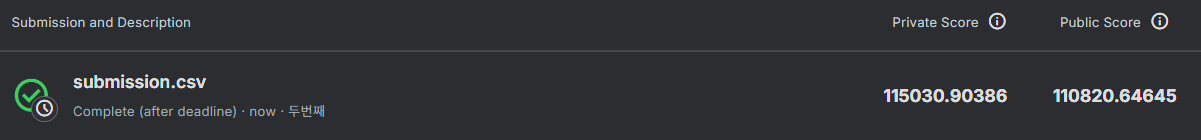

## 5. Add. Preprocessing
빨리자고싶어서 파라미터 튜닝 열심히했는데 점수가 거의그대로 ㅠㅠ 전처리를 해야할것같아요
면적대비 가격을 띄워볼게요

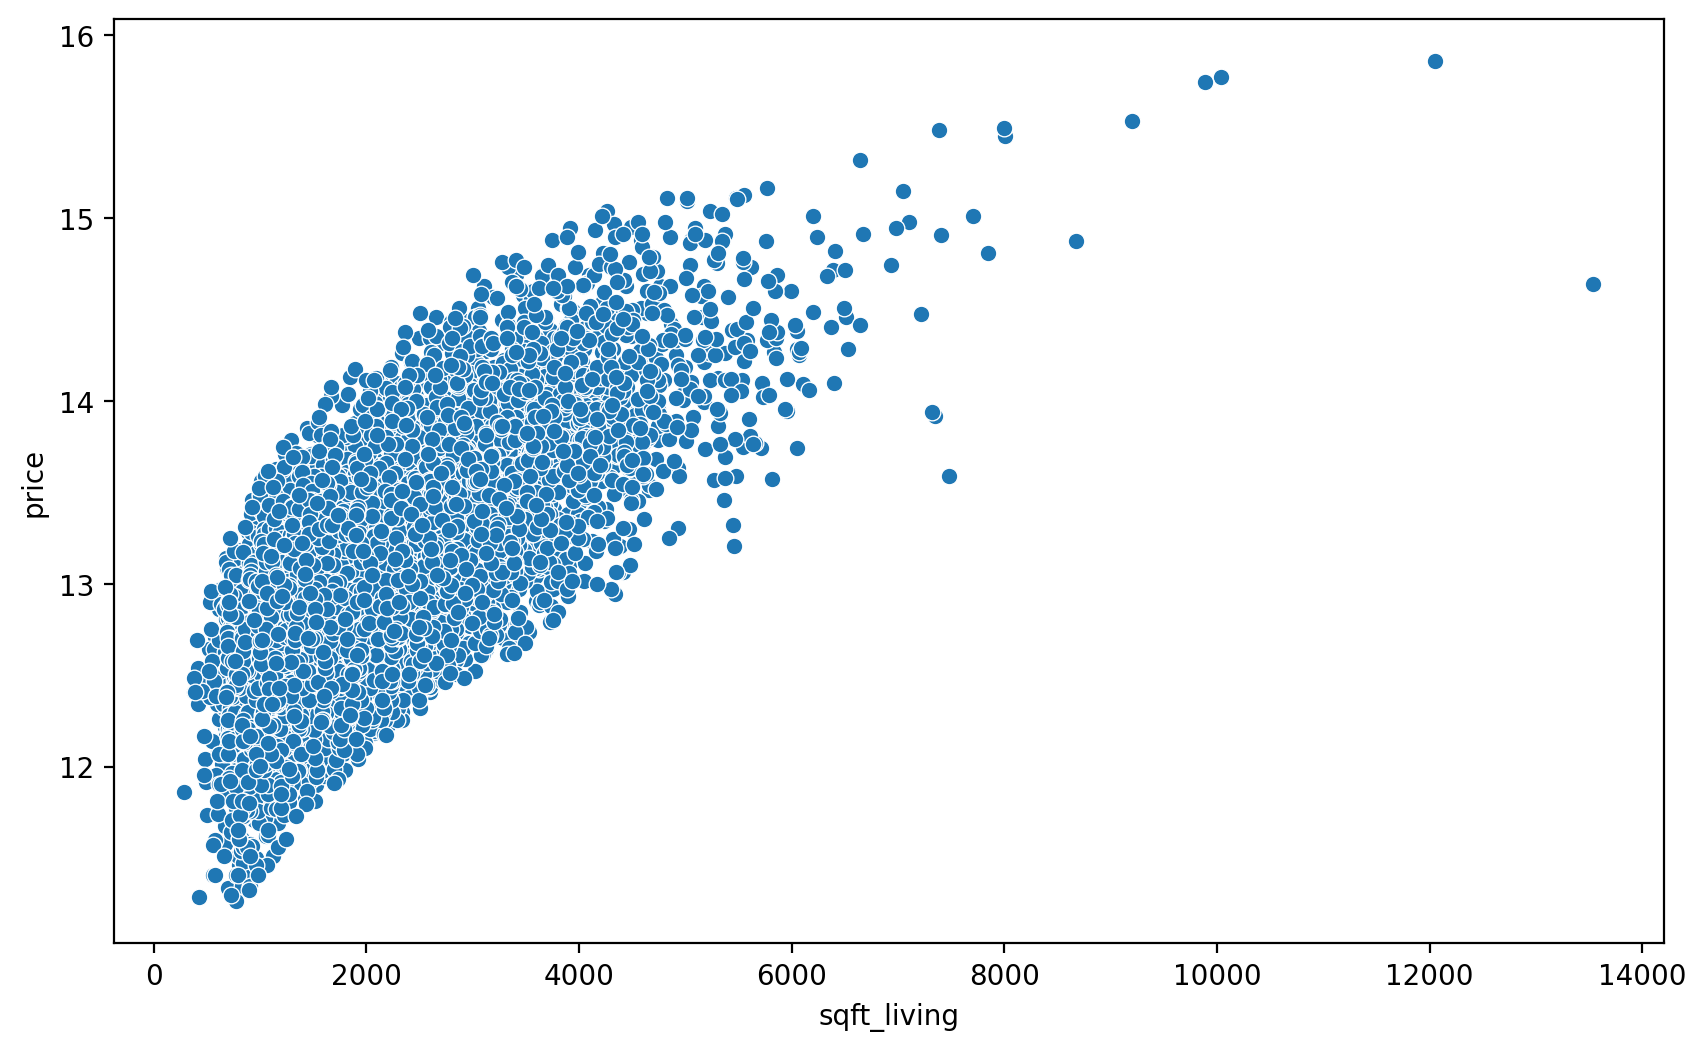

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=train['sqft_living'], y=y) # y는 로그 변환된 가격
plt.show()

### 분석
대충 멀리떨어진 10개와 군집한곳에서 떨어진것 도 상당수 보이네요 outlier를 훈련에서 제외만해줘도 잠을 잘수있겠어요!

지금 sqft_living이 6000이하인곳에 빼곡하게 군집해있고 
6000 ~ 7000은 살짝떨어져있는것들 엄청 많이 겹쳐있음.
7000 ~ 9000에는 최소 20개정도 있고
9000+는 완전 없애버려도 될듯.
사실 데이터수 15000개 생각하면 7500위로는 없애버려도 될것같음. 하지만 이걸 어떻게 ? 7500이상인 데이터가 몇개인지 부터 보자.

In [71]:
outliers_7500 = train[train['sqft_living'] > 7500]
len(outliers_7500)

10

In [72]:
outliers_7500

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
842,201410,5,5.25,8010,45517,2.0,1,4,3,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
1045,201504,5,5.00,8000,23985,2.0,0,4,3,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
2775,201406,5,4.50,10040,37325,2.0,1,2,3,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
3134,201408,5,5.75,9200,35069,2.0,0,0,3,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
5108,201410,6,8.00,12050,27600,2.5,0,3,4,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
6469,201409,6,7.75,9890,31374,2.0,0,4,3,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
8912,201405,7,8.00,13540,307752,3.0,0,4,3,12,9410,4130,1999,0,98053,47.6675,-121.986,4850,217800
10152,201406,5,6.25,8670,64033,2.0,0,4,3,13,6120,2550,1965,2003,98177,47.7295,-122.372,4140,81021
12845,201410,8,4.00,7710,11750,3.5,0,0,5,12,6090,1620,1904,0,98112,47.6263,-122.314,4210,8325
13809,201501,4,4.00,7850,89651,2.0,0,0,3,12,7850,0,2006,0,98027,47.5406,-121.982,6210,95832


In [73]:
outliers_7000 = train[train['sqft_living'] > 7000]
len(outliers_7000)

18

In [74]:
outliers_6500 = train[train['sqft_living'] > 6500]
len(outliers_6500)

25

In [75]:
outliers_6000 = train[train['sqft_living'] > 6000]
len(outliers_6000)

44

In [76]:
# 면적(sqft_living)과 타겟값(y)을 함께 출력
# 만약 y가 이미 로그 변환된 상태라면 np.expm1(y)로 원래 가격도 확인해봅시다.
print(outliers_7000[['sqft_living']])
print("로그 변환된 가격(y):", y[outliers_7000.index].values)

       sqft_living
842           8010
947           7390
1045          8000
1941          7350
2775         10040
2859          7480
3134          9200
4592          7220
4957          7050
5108         12050
5560          7100
6469          9890
7246          7400
8912         13540
10152         8670
12845         7710
12921         7320
13809         7850
로그 변환된 가격(y): [15.4468667  15.48321757 15.49260731 13.91987147 15.7703098  13.59236826
 15.53290579 14.47819905 15.15051189 15.85673102 14.97866168 15.74485584
 14.9084404  14.63968644 14.87607513 15.00943333 13.94236433 14.8087627 ]


#### 갯수로 봤을때는 6000위로 44개 다지워도 될것같지만 과적합이 올수있으니 7000위로 18개를 제거해주겠습니다.

In [77]:
# 1. 7,000 이상의 데이터를 지운 실험용 데이터 생성
outlier_indices = train[train['sqft_living'] >= 7000].index
train_reduced = train.drop(outlier_indices)
y_reduced = y.drop(outlier_indices)

# 2. 동일한 모델과 KFold 설정 사용
# (final_model과 kf는 이전에 정의한 것을 그대로 사용합니다)
mse_scores_new = cross_val_score(final_model, train_reduced, y_reduced, cv=kf, scoring='neg_mean_squared_error')
rmse_scores_new = np.sqrt(-mse_scores_new)

# 3. 결과 출력 및 비교
print(f"이상치 제거 후 평균 RMSE: {np.mean(rmse_scores_new):.4f}")
print(f"기존 대비 변화량: {np.mean(rmse_scores_new) - 0.1599:.4f}")

이상치 제거 후 평균 RMSE: 0.1601
기존 대비 변화량: 0.0002


오히려 점수가 떨어졌네요 ㅠㅠ

In [78]:
# 1. 7,000 이상의 데이터를 지운 실험용 데이터 생성
outlier_indices = train[train['sqft_living'] >= 6000].index
train_reduced = train.drop(outlier_indices)
y_reduced = y.drop(outlier_indices)

# 2. 동일한 모델과 KFold 설정 사용
# (final_model과 kf는 이전에 정의한 것을 그대로 사용합니다)
mse_scores_new = cross_val_score(final_model, train_reduced, y_reduced, cv=kf, scoring='neg_mean_squared_error')
rmse_scores_new = np.sqrt(-mse_scores_new)

# 3. 결과 출력 및 비교
print(f"이상치 제거 후 평균 RMSE: {np.mean(rmse_scores_new):.4f}")
print(f"기존 대비 변화량: {np.mean(rmse_scores_new) - 0.1599:.4f}")

이상치 제거 후 평균 RMSE: 0.1600
기존 대비 변화량: 0.0001


시간 살살 녹는다.... 6000~8000값을 바꿔가면해봤지만 오히려 안좋아짐.. 이방법은 패스할게요

그렇다면 남은방법은... Ensemble! 검색해보니 LGBM, XGBoost, CatBoost를 함께사용하는 방법을 추천하네요

튜닝 하지않고 한번 테스트해보겠습니다

In [79]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

xgb = XGBRegressor(
    n_estimators=500,     
    learning_rate=0.05, 
    max_depth=7,          
    random_state=42
)

# 교차 검증으로 점수 확인
scores = cross_val_score(xgb, train, y, cv=kf, scoring='neg_mean_squared_error')
rmse = np.sqrt(-scores.mean())
print(f"XGBoost RMSE: {rmse:.4f}")

XGBoost RMSE: 0.1620


밤 9시 30분인데 catboost 설치하다가 멈추더니 주피터환경 리셋되서 전체컴파일하는데 중간에 에러나네요
어떤 셀이 저장이안된건지... 전체다 리뷰할시간이 도저히안될거같아서 포기합니다. 마지막에 제출한것 입니다.
회고록 쓰고싶은데 새로운개념 좀 정리할시간이 부족해서 못할것같아요ㅠ
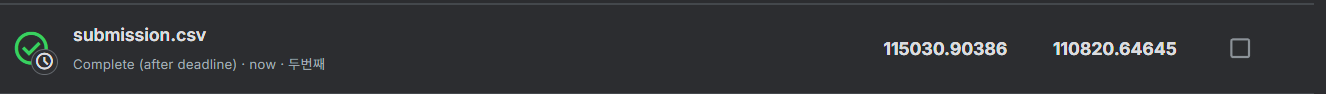

In [80]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score

# 1. CatBoost 파라미터 설정
# depth는 보통 6~10 사이가 적당하며, CatBoost는 대칭 트리라 10을 넘기면 매우 느려집니다.
cat_params = {
    'n_estimators': 500,          # XGB와 맞춤
    'learning_rate': 0.05,        # XGB와 맞춤
    'depth': 7,                   # XGB의 max_depth와 대응
    'l2_leaf_reg': 3,             # L2 정규화 (과적합 방지용 기본값)
    'random_state': 42,
    'verbose': 0                  # 학습 과정 출력 생략
}

# 2. 모델 생성
cat = CatBoostRegressor(**cat_params)

# 3. 교차 검증으로 점수 확인 (kf는 이미 정의하신 것으로 가정)
# scoring='neg_mean_squared_error'를 사용하여 점수를 계산합니다.
cat_scores = cross_val_score(cat, train, y, cv=kf, scoring='neg_mean_squared_error')

# 4. RMSE 계산
cat_rmse = np.sqrt(-cat_scores.mean())
print(f"CatBoost RMSE: {cat_rmse:.4f}")

CatBoost RMSE: 0.1595


In [81]:
final_model.fit(train, y) #LGBM
xgb.fit(train, y)
cat.fit(train, y)

lgbm_pred = final_model.predict(test)
xgb_pred = xgb.predict(test)
cat_pred = cat.predict(test)


In [83]:
# 평균 내기
final_pred = (lgbm_pred + xgb_pred + cat_pred) / 3
final_pred

array([13.11988396, 13.07375392, 14.14460114, ..., 13.03728859,
       12.66726938, 12.96411822], shape=(6468,))

In [84]:
# 성적이 좋은 Cat과 LGBM에 40%씩, XGB에 20% 비중 부여
final_pred = (lgbm_pred * 0.4) + (cat_pred * 0.4) + (xgb_pred * 0.2)

In [85]:
# 로그 변환 원래 스케일로 변환
final_submission_pred = np.expm1(final_pred)

In [88]:
submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)
submission.head()

# 결과 데이터채우기
result = pd.DataFrame({
    'id' : submission['id'],
    'price' : final_submission_pred
})

result.head()

,id,price
0,15035,5.020720e+05
1,15036,4.685688e+05
2,15037,1.383701e+06
3,15038,3.021734e+05
4,15039,3.273778e+05


In [89]:
my_submission_path = join(data_dir, 'submission.csv')
result.to_csv(my_submission_path, index=False)

print(my_submission_path)

data\submission.csv


In [ ]:
submission.csv
Complete (after deadline) · now · 찐막
private 112544.90818

public 107633.21340

